Project 2

Description: Project report 2 should naturally follow project report 1 on ”Data: Feature extraction, and
visualization” and cover what you have learned in the lectures and exercises of week 5 to 8 on
”Supervised learning: Classification and regression”. The report should therefore include two
02452 PROJECT 2 Fall 2025
sections. A section on regression and a section on classification. The report will be evaluated
based on how it addresses each of the questions asked below and an overall assessment of the
report quality


Importing Relevant Packages

In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
from scipy.io import loadmat
import torch

import sklearn.linear_model as lm
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut
from sklearn.decomposition import PCA
from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso


# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

def setup_storage_for_experiment(K_outer, K_inner, num_hyperparams):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_hyperparameters = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_hyperparams))
    train_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))
    test_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'not regularized': np.empty((M + 1, K_outer)),
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        },
        'test': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        }
    }
    return optimal_hyperparameters, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer

def get_grid_points(x_min, x_max, y_min, y_max, delta=5e-3):
    # Create a grid of points with the specified resolution
    xx = np.arange(x_min, x_max, delta)
    yy = np.arange(y_min, y_max, delta)
    # Make a mesh-grid that spans the grid-range defined
    grid = np.stack(np.meshgrid(xx, yy))
    return grid, xx, yy

def plot_decision_boundary(predict_function, X, threshold=None, fig=None, cmap='RdBu_r'):
    # Set grid range based on the data
    grid_range = [X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()]  # [x_min, x_max, y_min, y_max]
    # Add 10% margin to the grid range to ensure points on the edge are included
    margin_x = 0.1 * (grid_range[1] - grid_range[0])
    margin_y = 0.1 * (grid_range[3] - grid_range[2])
    grid_range[0] -= margin_x
    grid_range[1] += margin_x
    grid_range[2] -= margin_y
    grid_range[3] += margin_y

    # Get grid points
    grid, xx, yy = get_grid_points(*grid_range, delta=5e-3)
    # Reshape grid to a list of points
    grid_points = torch.tensor(np.reshape(grid, (2, -1)).T, dtype=torch.float32)

    # Compute model predictions on the grid points (i.e. the probability of class 1)
    with torch.no_grad():  # No need to compute gradients for plotting
        grid_predictions = predict_function(grid_points)

    # Reshape the predictions back to the grid shape
    decision_boundary = np.reshape(grid_predictions, (len(yy), len(xx)))

    # Setup figure and axis for plotting
    if fig is None:
        fig = plt.figure(figsize=(6, 6))
    ax = fig.gca()

    # Plot the decision boundary
    img = ax.imshow(decision_boundary, extent=grid_range, origin='lower', cmap=cmap, alpha=0.5)
    fig.colorbar(img, ax=ax)
    if threshold is not None:
        ax.contour(grid[0], grid[1], decision_boundary, levels=[threshold], colors='k')
    ax.grid(False)
    ax.set_aspect('auto')

def print_regularization_results(errors):
    # Display results
    print("Linear regression without regularization:")
    print(f"- Training error: \t{errors['train']['not regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['not regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['not regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['not regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

    print("Regularized linear regression:")
    print(f"- Training error: \t{errors['train']['regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")


# Regression

## Part A

1. Explain what variable is predicted based on which other variables and what you hope to
accomplish by the regression. Mention your feature transformation choices such as one-ofK coding. Since we will use regularization momentarily, apply a feature transformation to
your data matrix X such that each column has mean 0 and standard deviation 1^1



In [2]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['mcg', 'class', 'Sequence Name'])
y = df['mcg']

#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N, M = X_scaled.shape
print(X_scaled)
print(columns)

[[-1.41953086 -0.17514236 -0.05463584  0.49078096 -1.20771743 -0.7160837 ]
 [-0.67596708 -0.17514236 -0.05463584  0.32710612 -0.69711074 -0.28566488]
 [-0.67596708 -0.17514236 -0.05463584 -0.08208098 -0.60427317 -0.19001625]
 ...
 [ 0.67596708 -0.17514236 -0.05463584 -0.49126808 -0.51143559 -0.57261076]
 [ 0.74356378 -0.17514236 -0.05463584 -0.65494292 -0.37217922 -0.62043507]
 [ 1.62232098 -0.17514236 -0.05463584 -1.55515454  0.13842746  0.09692964]]
['Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']


2. Introduce a regularization parameter λ as discussed in 14 of the lecture notes, and estimate
the generalization error for different values of λ. Specifically, choose a reasonable range of
values of λ (ideally one where the generalization error first drop and then increases), and
for each value use K = 10 fold cross-validation (algorithm 5) to estimate the generalization
error. Include a figure of the estimated generalization error as a function of λ in the report
and briefly discuss the result

In [3]:
seed = np.random.seed(1234)
lambdas = np.logspace(-5, 8, 50)

train_errors = []
test_errors = []

kf = KFold(n_splits=10, shuffle=True, random_state=seed)

for lam in lambdas:
    ridge = Ridge(alpha=lambdas)

    fold_train_errors = []
    fold_test_errors = []

    for train_index, test_index in kf.split(X_scaled):
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        ridge.fit(X_train, y_train)

        y_train_pred = ridge.predict(X_train)
        y_test_pred = ridge.predict(X_test)

        train_mse = np.mean((y_train - y_train_pred) ** 2)
        test_mse = np.mean((y_test - y_test_pred) ** 2)

        fold_train_errors.append(train_mse)
        fold_test_errors.append(test_mse)


    


ValueError: Number of targets and number of penalties do not correspond: 50 != 1

In [ ]:
X = X_scaled

y = y.to_numpy()

# Set random seed for reproducibility
np.random.seed(1234)

# Create crossvalidation partition for model evaluation
K_outer = 10
CV_outer = model_selection.KFold(K_outer, shuffle=True)

# Create crossvalidation partition for hyperparameter tuning
K_inner = 10
CV_inner = model_selection.KFold(K_inner, shuffle=True)

# Values of regularization parameter lambda to test in the inner loop
lambdas = np.logspace(-5, 8, 50)

# Setup storage for the experiment
optimal_regularization_strengths, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer = setup_storage_for_experiment(K_outer, K_inner, len(lambdas))

# Run two-layer cross-validation
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(CV_outer.split(X, y)):
    # Extract training and test set for the current outer CV fold
    X_train_outer, y_train_outer = X[outer_train_index], y[outer_train_index]
    X_test_outer, y_test_outer = X[outer_test_index], y[outer_test_index]

    # Loop over inner cross-validation folds
    for inner_fold_idx, (inner_train_index, inner_test_index) in enumerate(CV_inner.split(X_train_outer, y_train_outer)):

        # Extract training and validation set for current inner CV fold
        X_train_inner, y_train_inner = X_train_outer[inner_train_index], y_train_outer[inner_train_index]
        X_test_inner, y_test_inner = X_train_outer[inner_test_index], y_train_outer[inner_test_index]

        # Compute the mean and standard deviation of the inner training data split, then standardize training and test sets
        ### BEGIN SOLUTION
        # Compute the mean and standard deviation of the inner training data split
        mu_inner = np.mean(X_train_inner, axis=0)
        sigma_inner = np.std(X_train_inner, axis=0)
        sigma_inner[sigma_inner == 0] = 1e-12  # To avoid division by zero
        
        # Standardize the inner training set and validation set
        X_train_inner = (X_train_inner - mu_inner) / sigma_inner
        X_test_inner = (X_test_inner - mu_inner) / sigma_inner
        ### END SOLUTION

        # Loop over all values of lambda
        for lambda_idx, regularization_strength in enumerate(lambdas):

            # Create and fit the model
            ### BEGIN SOLUTION
            model = Ridge(alpha=regularization_strength)
            model.fit(X_train_inner, y_train_inner)
            ### END SOLUTION

            # Store the model coefficients for each value of lambda in the inner folds
            ws_inner[:, outer_fold_idx, inner_fold_idx, lambda_idx] = [model.intercept_] + model.coef_.flatten().tolist()

            # Compute and store the training and validation error
            train_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_train_inner - model.predict(X_train_inner))**2, axis=0)
            test_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_test_inner - model.predict(X_test_inner))**2, axis=0)
    
    # Determine the optimal value of lambda that gives the lowest test error on average from the inner folds
    ### BEGIN SOLUTION
    optimal_hyperparameter_idx = np.argmin(np.mean(test_errors_inner[outer_fold_idx], axis=0))
    optimal_hyperparameter = lambdas[optimal_hyperparameter_idx]
    ### END SOLUTION

    # Store the optimal regularization strength for the current outer fold
    optimal_regularization_strengths[outer_fold_idx] = optimal_hyperparameter

    # Compute the mean and standard deviation of the outer training data split, then standardize the training and test sets
    ### BEGIN SOLUTION
    # Compute the mean and standard deviation of the outer training data split
    mu_outer = np.mean(X_train_outer, axis=0)
    sigma_outer = np.std(X_train_outer, axis=0)
    sigma_outer[sigma_outer == 0] = 1e-12  # To avoid division by zero

    # Standardize the outer training set and test set
    X_train_outer = (X_train_outer - mu_outer) / sigma_outer
    X_test_outer = (X_test_outer - mu_outer) / sigma_outer
    ### END SOLUTION

    # Create and fit the model with the optimal lambda on the entire outer training set
    ### BEGIN SOLUTION
    model = Ridge(alpha=optimal_hyperparameter)
    model.fit(X_train_outer, y_train_outer)
    ### END SOLUTION

    # Store the model coefficients for the regularized model
    ws_outer['regularized'][:, outer_fold_idx] = [model.intercept_] + model.coef_.flatten().tolist()
    # Compute and store the training and test error for the regularized model
    errors_outer['train']['regularized'][outer_fold_idx] = np.mean((y_train_outer - model.predict(X_train_outer))**2, axis=0)
    errors_outer['test']['regularized'][outer_fold_idx] = np.mean((y_test_outer - model.predict(X_test_outer))**2, axis=0)


    # Create and fit a model without regularization on the entire outer training set, for comparison
    model = LinearRegression()
    model.fit(X_train_outer, y_train_outer)

    # Store the model coefficients for the model without regularization
    ws_outer['not regularized'][:, outer_fold_idx] = [model.intercept_] + model.coef_.flatten().tolist()
    # Compute and store the training and test error for the model without regularization
    errors_outer['train']['not regularized'][outer_fold_idx] = np.mean((y_train_outer - model.predict(X_train_outer))**2, axis=0)
    errors_outer['test']['not regularized'][outer_fold_idx] = np.mean((y_test_outer - model.predict(X_test_outer))**2, axis=0)

    # Compute mean squared error for the baseline, i.e. without using the input data at all
    errors_outer['train']['baseline (no features)'][outer_fold_idx] = np.mean((y_train_outer - y_train_outer.mean())**2, axis=0)
    errors_outer['test']['baseline (no features)'][outer_fold_idx] = np.mean((y_test_outer - y_test_outer.mean())**2, axis=0)

# Print results
print_regularization_results(errors_outer)

NameError: name 'M' is not defined

In [ ]:
selected_inner_fold = -1
selected_outer_fold = -1

# Get the weights for the selected outer and inner fold from ws_inner. Compare the bias term to the mean of the target variable in the training set.
### BEGIN SOLUTION
print(f"Weights for outer fold {selected_outer_fold} and inner fold {selected_inner_fold}:")
# Extract and print the weights for the selected fold
print(ws_inner[:, selected_outer_fold, selected_inner_fold, -1])

# Print the mean of the target variable in the training set for the last inner fold of the last outer fold
print(f"\nMean of target variable in training set: {np.mean(y_train_inner):.5f}")
# Compare the bias term (first entry) to the mean of the target variable
print(f"Bias term (intercept) from model: {ws_inner[0, selected_outer_fold, selected_inner_fold, -1]:.5f}")
### END SOLUTION

Weights for outer fold -1 and inner fold -1:
[4.99267399e-01 2.58458858e-07 7.62437227e-08 4.15037384e-08
 1.26042805e-07 2.17705107e-07 9.26790654e-08]

Mean of target variable in training set: 0.49927
Bias term (intercept) from model: 0.49927


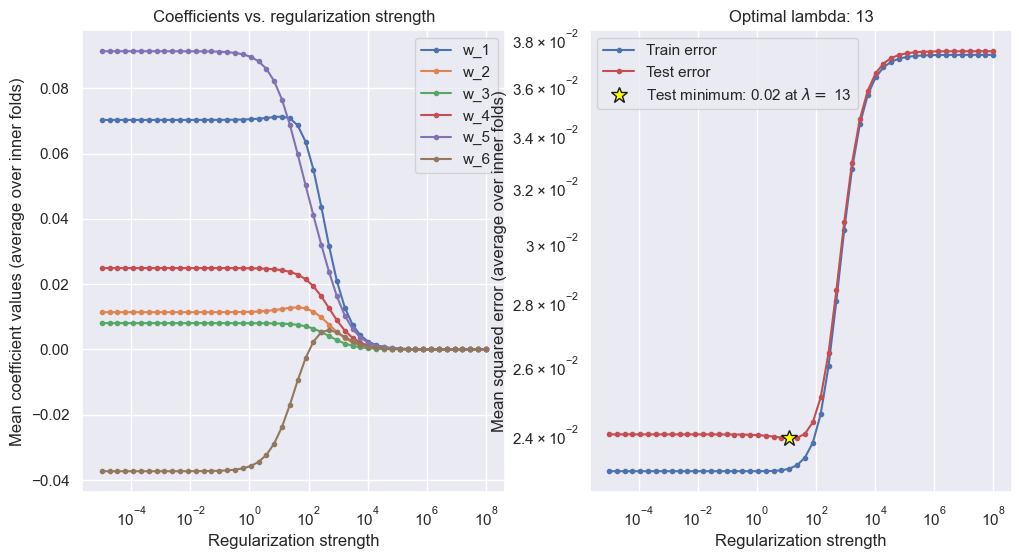

In [ ]:
# Compute the mean training and validation error across inner folds for the selected outer fold
train_err_vs_lambda = np.mean(train_errors_inner[selected_outer_fold], axis=0)
test_err_vs_lambda = np.mean(test_errors_inner[selected_outer_fold], axis=0)

# Compute the mean coefficients across inner folds for the selected outer fold
mean_w_vs_lambda = np.squeeze(np.mean(ws_inner[:, selected_outer_fold, :, :], axis=1))


# Setup figure
plt.figure(figsize=(12, 6))

# Plot the mean coefficients across inner folds vs regularization strength for the selected outer fold
plt.subplot(1, 2, 1)
plt.title("Coefficients vs. regularization strength")
plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:], ".-")  # Don't plot the bias term
plt.xlabel("Regularization strength")
plt.ylabel("Mean coefficient values (average over inner folds)")
plt.legend([f"w_{i}" for i in range(1, mean_w_vs_lambda.shape[0])])

# Plot the mean training and validation error vs regularization strength for the selected outer fold
plt.subplot(1, 2, 2)
plt.title(f"Optimal lambda: {optimal_regularization_strengths[selected_outer_fold]:.2g}")
plt.loglog(lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-")
plt.semilogx(optimal_regularization_strengths[selected_outer_fold], test_err_vs_lambda.min(), "*", color='yellow', markersize=12, markeredgecolor='k')
plt.xlabel("Regularization strength")
plt.ylabel("Mean squared error (average over inner folds)")
plt.legend(["Train error", "Test error", r"Test minimum: {:.2f} at $\lambda=$ {:.2g}".format(test_err_vs_lambda.min(), optimal_regularization_strengths[selected_outer_fold])])
plt.show()

3. Explain how the output, y, of the linear model with the lowest generalization error (as
determined in the previous question) is computed for a given input x. What is the effect
of an individual attribute in x on the output, y, of the linear model? Does the effect of
individual attributes make sense based on your understanding of the problem?

In [ ]:
# Assuming your 6 features are the first 6 columns of df (index 0 to 5)
feature_names = df.columns[2:8].tolist()
# The weights list must include the 'Intercept' first, then the features
coefficient_index = ['Intercept'] + feature_names

# Corrected code for DataFrame creation:
unregularized = pd.DataFrame(ws_outer['not regularized'],
    index=coefficient_index,  # Length 7
    columns=[f'Outer fold {i+1}' for i in range(K_outer)]
).T

regularized = pd.DataFrame(
    ws_outer['regularized'],
    index=coefficient_index,  # Length 7
    columns=[f'Outer fold {i+1}' for i in range(K_outer)]
).T

display(unregularized, regularized)

,Intercept,gvh,lip,chg,aac,alm1,alm2
Outer fold 1,0.498411,0.067069,0.008939,9.914300e-03,0.021814,0.083133,-0.036061
Outer fold 2,0.495364,0.070343,0.013974,9.583736e-03,0.023261,0.079538,-0.021633
Outer fold 3,0.505596,0.070096,0.015069,8.179847e-03,0.022072,0.081222,-0.028640
Outer fold 4,0.496722,0.071854,0.011815,9.416744e-03,0.025189,0.074100,-0.031142
Outer fold 5,0.495033,0.066005,0.008817,9.791369e-03,0.019446,0.090054,-0.033865
Outer fold 6,0.501225,0.065470,0.011624,9.729299e-03,0.023119,0.085405,-0.025843
Outer fold 7,0.502211,0.064591,0.008011,-1.647987e-17,0.020693,0.095219,-0.038937
Outer fold 8,0.505974,0.066394,0.012459,8.850825e-03,0.018114,0.079742,-0.030357
Outer fold 9,0.502112,0.066472,0.012813,9.208713e-03,0.024702,0.077785,-0.033193
Outer fold 10,0.497921,0.070318,0.011443,8.455061e-03,0.024890,0.091082,-0.037051


,Intercept,gvh,lip,chg,aac,alm1,alm2
Outer fold 1,0.498411,0.065301,0.012021,0.008667,0.020275,0.057574,-0.013540
Outer fold 2,0.495364,0.069044,0.015444,0.009030,0.022565,0.063985,-0.008263
Outer fold 3,0.505596,0.070338,0.016183,0.007918,0.022141,0.070183,-0.018836
Outer fold 4,0.496722,0.070862,0.013367,0.008843,0.024233,0.058584,-0.017134
Outer fold 5,0.495033,0.064653,0.012125,0.008610,0.018043,0.060961,-0.008451
Outer fold 6,0.501225,0.065024,0.013489,0.009073,0.021992,0.068622,-0.011236
Outer fold 7,0.502211,0.065475,0.008968,0.000000,0.020393,0.086504,-0.030877
Outer fold 8,0.505974,0.066271,0.014205,0.008323,0.017459,0.062544,-0.015037
Outer fold 9,0.502112,0.066612,0.013980,0.008866,0.024012,0.067211,-0.023470
Outer fold 10,0.497921,0.071304,0.012335,0.008323,0.024309,0.077497,-0.024594


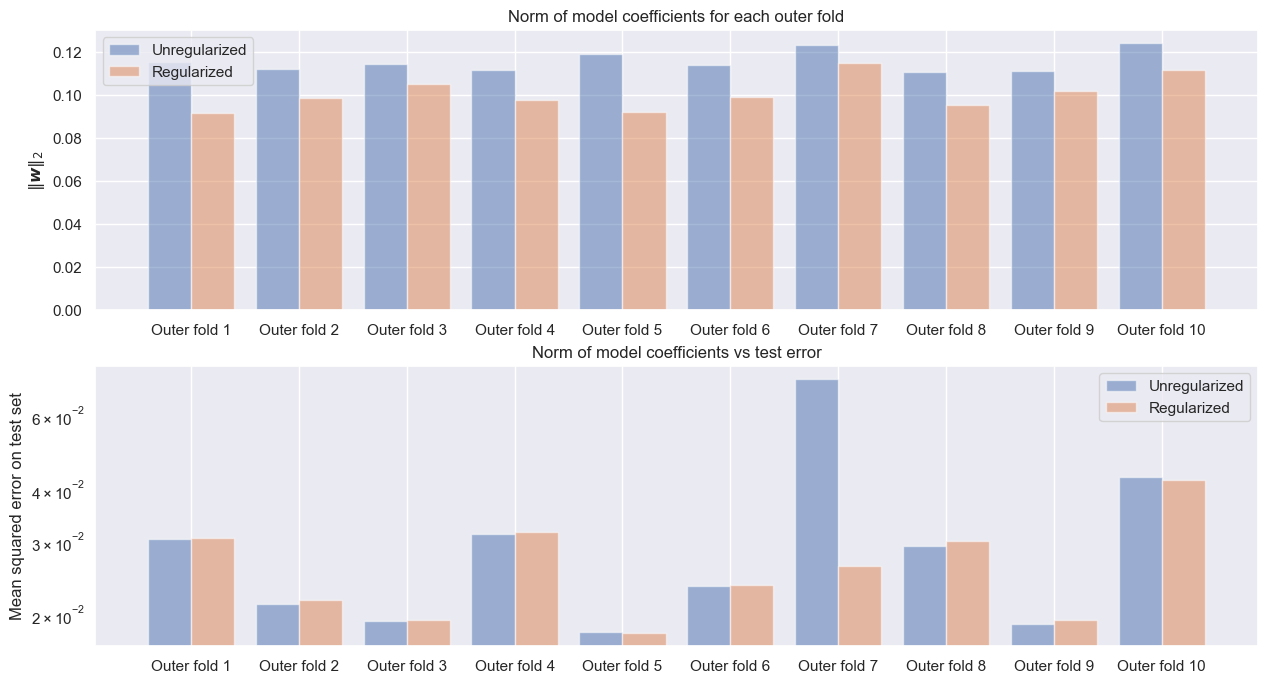

In [ ]:
# Compute the L2 norm of the model coefficients for each outer fold (excluding the intercept) for the regularized and unregularized model
### BEGIN SOLUTION
unregularized_norm = np.linalg.norm(unregularized.iloc[:, 1:], ord=2, axis=1)
regularized_norm = np.linalg.norm(regularized.iloc[:, 1:], ord=2, axis=1)
### END SOLUTION

fig, axs = plt.subplots(2, 1, figsize=(15, 8))
# Plot the L2 norms
axs[0].bar(np.arange(K_outer)-0.2, np.linalg.norm(unregularized.iloc[:, 1:], axis=1), width=0.4, alpha=0.5, label='Unregularized')
axs[0].bar(np.arange(K_outer)+0.2, regularized_norm, width=0.4, alpha=0.5, label='Regularized')
axs[0].set_ylabel(r'$\|\boldsymbol{w}\|_2$')
axs[0].set_xticks(ticks=np.arange(K_outer), labels=unregularized.index, rotation=0)
axs[0].set_title('Norm of model coefficients for each outer fold')
axs[0].legend()

axs[1].bar(np.arange(K_outer)-0.2, errors_outer['test']['not regularized'].flatten(), width=0.4, alpha=0.5, label='Unregularized')
axs[1].bar(np.arange(K_outer)+0.2, errors_outer['test']['regularized'].flatten(), width=0.4, alpha=0.5, label='Regularized')
axs[1].set_xticks(ticks=np.arange(K_outer), labels=unregularized.index, rotation=0)
axs[1].set_ylabel('Mean squared error on test set')
axs[1].set_yscale('log')
axs[1].set_title('Norm of model coefficients vs test error')
axs[1].legend()
plt.show()

Regression, part b: In this section, we will compare three models: the regularized linear regression model from the previous section, an artificial neural network (ANN) and a baseline. We
are interested in two questions: Is one model better than the other? Is either model better than
a trivial baseline?. We will attempt to answer these questions with two-level cross-validation.


1. Implement two-level cross-validation (see algorithm 6 of the lecture notes). We will use
2-level cross-validation to compare the models with K1 = K2 = 10 folds2
. As a baseline
model, we will apply a linear regression model with no features, i.e. it computes the mean
of y on the training data, and use this value to predict y on the test data.
Make sure you can fit an ANN model to the data. As complexity-controlling parameter
for the ANN, we will use the number of hidden units3 h. Based on a few test-runs, select
a reasonable range of values for h (which should include h = 1), and describe the range of
values you will use for h and λ.

# Classification

## Retrieve and klargør data


In [9]:
# Loading the data
columns = [
    'Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'
]

df = pd.read_fwf("data/ecoli.data", header=None, names=columns)

# Define predictors (X) and target (y)
X = df.drop(columns=['class', 'Sequence Name'])
y = df['class']


#Scaling X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
N, M = X_scaled.shape

# Ensure X is a numpy array for proper indexing (not a DataFrame)
X = np.asarray(X_scaled)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(f"Converted class labels to integers. Class mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

print(X_scaled)
print(columns)

Converted class labels to integers. Class mapping: {'cp': 0, 'im': 1, 'mL': 2, 'mS': 3, 'mU': 4, 'om': 5, 'pp': 6}
[[-0.0517614  -1.41953086 -0.17514236 ...  0.49078096 -1.20771743
  -0.7160837 ]
 [-2.21287637 -0.67596708 -0.17514236 ...  0.32710612 -0.69711074
  -0.28566488]
 [ 0.30842443 -0.67596708 -0.17514236 ... -0.08208098 -0.60427317
  -0.19001625]
 ...
 [ 0.56570002  0.67596708 -0.17514236 ... -0.49126808 -0.51143559
  -0.57261076]
 [ 0.46278978  0.74356378 -0.17514236 ... -0.65494292 -0.37217922
  -0.62043507]
 [ 1.23461656  1.62232098 -0.17514236 ... -1.55515454  0.13842746
   0.09692964]]
['Sequence Name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class']


### 

## Multi class classification (2-layer cross validation)

In [ ]:
# Ensure X and y are numpy arrays for proper indexing
X = np.asarray(X_scaled) if 'X_scaled' in locals() or 'X_scaled' in globals() else np.asarray(X)
if hasattr(y, 'to_numpy'):
    y = y.to_numpy()
else:
    y = np.asarray(y)

# Set random seed for reproducibility
np.random.seed(1234)

# Create crossvalidation partition for model evaluation
K_outer = 10
CV_outer = model_selection.KFold(K_outer, shuffle=True)

# Create crossvalidation partition for hyperparameter tuning
K_inner = 10
CV_inner = model_selection.KFold(K_inner, shuffle=True)

# Values of regularization parameter lambda to test in the inner loop (for logistic regression)
lambdas = np.logspace(-10, 10, 50)

# Values of k to test in the inner loop (for KNN)
k_values = np.arange(1, 21, dtype=int)  # k from 1 to 20

# Setup storage for the experiment
# For logistic regression
lr_errors_inner = {'train': np.empty((K_outer, K_inner, len(lambdas))), 
                   'test': np.empty((K_outer, K_inner, len(lambdas)))}
optimal_lambdas = np.empty(K_outer)

# For KNN
knn_errors_inner = {'train': np.empty((K_outer, K_inner, len(k_values))), 
                    'test': np.empty((K_outer, K_inner, len(k_values)))}
optimal_k_values = np.empty(K_outer, dtype=int)

# For outer fold results
results = {
    'logistic_regression': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer),
        'optimal_lambda': np.empty(K_outer)
    },
    'knn': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer),
        'optimal_k': np.empty(K_outer)
    },
    'baseline': {
        'train_error': np.empty(K_outer),
        'test_error': np.empty(K_outer)
    }
}

# Run two-layer cross-validation
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(CV_outer.split(X, y)):
    # Extract training and test set for the current outer CV fold
    # Convert to numpy arrays to ensure proper positional indexing (not label-based)
    X_train_outer = np.asarray(X[outer_train_index])
    y_train_outer = np.asarray(y[outer_train_index])
    X_test_outer = np.asarray(X[outer_test_index])
    y_test_outer = np.asarray(y[outer_test_index])

    # Loop over inner cross-validation folds
    for inner_fold_idx, (inner_train_index, inner_test_index) in enumerate(CV_inner.split(X_train_outer, y_train_outer)):

        # Extract training and validation set for current inner CV fold
        # Convert to numpy arrays to ensure proper positional indexing (not label-based)
        X_train_inner = np.asarray(X_train_outer[inner_train_index])
        y_train_inner = np.asarray(y_train_outer[inner_train_index])
        X_test_inner = np.asarray(X_train_outer[inner_test_index])
        y_test_inner = np.asarray(y_train_outer[inner_test_index])

        # Compute the mean and standard deviation of the inner training data split, then standardize training and test sets
        # YOUR CODE HERE
        mean_inner = X_train_inner.mean(axis=0)
        std_inner = X_train_inner.std(axis=0)
        # Avoid division by zero
        std_inner[std_inner == 0] = 1e-12
        X_train_inner = (X_train_inner - mean_inner) / std_inner
        X_test_inner = (X_test_inner - mean_inner) / std_inner

        # Hyperparameter tuning for Logistic Regression
        for lambda_idx, regularization_strength in enumerate(lambdas):
            # Use softmax (multinomial) logistic regression for multi-class classification
            # Note: C = 1/lambda in sklearn (inverse relationship)
            model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0/regularization_strength, max_iter=100000, random_state=1234)
            model_lr.fit(X_train_inner, y_train_inner)
            
            # Compute and store the training and validation error (0-1 loss: 1 if misclassified, 0 if correct)
            y_train_inner_pred_lr = model_lr.predict(X_train_inner)
            y_test_inner_pred_lr = model_lr.predict(X_test_inner)
            lr_errors_inner['train'][outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean(y_train_inner != y_train_inner_pred_lr)
            lr_errors_inner['test'][outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean(y_test_inner != y_test_inner_pred_lr)
        
        # Hyperparameter tuning for KNN
        for k_idx, k in enumerate(k_values):
            model_knn = KNeighborsClassifier(n_neighbors=k)
            model_knn.fit(X_train_inner, y_train_inner)
            
            # Compute and store the training and validation error (0-1 loss: 1 if misclassified, 0 if correct)
            y_train_inner_pred_knn = model_knn.predict(X_train_inner)
            y_test_inner_pred_knn = model_knn.predict(X_test_inner)
            knn_errors_inner['train'][outer_fold_idx, inner_fold_idx, k_idx] = np.mean(y_train_inner != y_train_inner_pred_knn)
            knn_errors_inner['test'][outer_fold_idx, inner_fold_idx, k_idx] = np.mean(y_test_inner != y_test_inner_pred_knn)
    
    # Determine the optimal hyperparameters from the inner folds
    # Optimal lambda for logistic regression
    optimal_lambda_idx = np.argmin(np.mean(lr_errors_inner['test'][outer_fold_idx], axis=0))
    optimal_lambda = lambdas[optimal_lambda_idx]
    optimal_lambdas[outer_fold_idx] = optimal_lambda
    
    # Optimal k for KNN
    optimal_k_idx = np.argmin(np.mean(knn_errors_inner['test'][outer_fold_idx], axis=0))
    optimal_k = k_values[optimal_k_idx]
    optimal_k_values[outer_fold_idx] = optimal_k

    # Compute the mean and standard deviation of the outer training data split, then standardize the training and test sets
    # YOUR CODE HERE
    mean_outer = X_train_outer.mean(axis=0)
    std_outer = X_train_outer.std(axis=0)
    # Avoid division by zero
    std_outer[std_outer == 0] = 1e-12
    X_train_outer = (X_train_outer - mean_outer) / std_outer
    X_test_outer = (X_test_outer - mean_outer) / std_outer

    # Evaluate Logistic Regression with optimal lambda on outer test set
    model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0/optimal_lambda, max_iter=100000, random_state=1234)
    model_lr.fit(X_train_outer, y_train_outer)
    y_train_outer_pred_lr = model_lr.predict(X_train_outer)
    y_test_outer_pred_lr = model_lr.predict(X_test_outer)
    results['logistic_regression']['train_error'][outer_fold_idx] = np.mean(y_train_outer != y_train_outer_pred_lr)
    results['logistic_regression']['test_error'][outer_fold_idx] = np.mean(y_test_outer != y_test_outer_pred_lr)
    results['logistic_regression']['optimal_lambda'][outer_fold_idx] = optimal_lambda

    # Evaluate KNN with optimal k on outer test set
    model_knn = KNeighborsClassifier(n_neighbors=optimal_k)
    model_knn.fit(X_train_outer, y_train_outer)
    y_train_outer_pred_knn = model_knn.predict(X_train_outer)
    y_test_outer_pred_knn = model_knn.predict(X_test_outer)
    results['knn']['train_error'][outer_fold_idx] = np.mean(y_train_outer != y_train_outer_pred_knn)
    results['knn']['test_error'][outer_fold_idx] = np.mean(y_test_outer != y_test_outer_pred_knn)
    results['knn']['optimal_k'][outer_fold_idx] = optimal_k

    # Evaluate Baseline (predict most common class)
    most_common_class = np.bincount(y_train_outer.astype(int)).argmax()
    baseline_train_pred = np.full(len(y_train_outer), most_common_class)
    baseline_test_pred = np.full(len(y_test_outer), most_common_class)
    results['baseline']['train_error'][outer_fold_idx] = np.mean(y_train_outer != baseline_train_pred)
    results['baseline']['test_error'][outer_fold_idx] = np.mean(y_test_outer != baseline_test_pred)

# Create results dataframe
results_df = pd.DataFrame({
    'Outer_Fold': range(1, K_outer + 1),
    'LR_Train_Error': results['logistic_regression']['train_error'],
    'LR_Test_Error': results['logistic_regression']['test_error'],
    'LR_Optimal_Lambda': results['logistic_regression']['optimal_lambda'],
    'KNN_Train_Error': results['knn']['train_error'],
    'KNN_Test_Error': results['knn']['test_error'],
    'KNN_Optimal_k': results['knn']['optimal_k'],
    'Baseline_Train_Error': results['baseline']['train_error'],
    'Baseline_Test_Error': results['baseline']['test_error']
})

# Display the results dataframe
print("Cross-Validation Results Summary:")
print("=" * 80)
display(results_df)

print("\nMean Errors Across All Outer Folds:")
print("-" * 80)
print(f"Logistic Regression - Train: {results_df['LR_Train_Error'].mean():.4f}, Test: {results_df['LR_Test_Error'].mean():.4f}")
print(f"KNN - Train: {results_df['KNN_Train_Error'].mean():.4f}, Test: {results_df['KNN_Test_Error'].mean():.4f}")
print(f"Baseline - Train: {results_df['Baseline_Train_Error'].mean():.4f}, Test: {results_df['Baseline_Test_Error'].mean():.4f}")
print(f"\nMean Optimal Lambda: {results_df['LR_Optimal_Lambda'].mean():.4f}")
print(f"Mean Optimal k: {results_df['KNN_Optimal_k'].mean():.1f}")

/opt/anaconda3/envs/dtu02452/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/dtu02452/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/dtu02452/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/dtu02452/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py

Cross-Validation Results Summary:


/opt/anaconda3/envs/dtu02452/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,Outer_Fold,LR_Train_Error,LR_Test_Error,LR_Optimal_Lambda,KNN_Train_Error,KNN_Test_Error,KNN_Optimal_k,Baseline_Train_Error,Baseline_Test_Error
0,1,0.105960,0.176471,0.625055,0.076159,0.264706,3.0,0.572848,0.588235
1,2,0.115894,0.029412,1.599859,0.112583,0.058824,7.0,0.586093,0.470588
2,3,0.105960,0.117647,0.244205,0.102649,0.147059,7.0,0.582781,0.500000
3,4,0.112583,0.117647,10.481131,0.109272,0.147059,7.0,0.576159,0.558824
4,5,0.109272,0.147059,1.599859,0.105960,0.117647,7.0,0.556291,0.735294
5,6,0.112583,0.088235,0.244205,0.115894,0.058824,7.0,0.566225,0.647059
6,7,0.089109,0.333333,10.481131,0.095710,0.242424,5.0,0.574257,0.575758
7,8,0.105611,0.121212,0.625055,0.125413,0.151515,8.0,0.577558,0.545455
8,9,0.112211,0.030303,4.094915,0.112211,0.030303,7.0,0.594059,0.393939
9,10,0.099010,0.212121,0.244205,0.122112,0.121212,7.0,0.557756,0.727273



Mean Errors Across All Outer Folds:
--------------------------------------------------------------------------------
Logistic Regression - Train: 0.1068, Test: 0.1373
KNN - Train: 0.1078, Test: 0.1340
Baseline - Train: 0.5744, Test: 0.5742

Mean Optimal Lambda: 3.0240
Mean Optimal k: 6.5


## Plots

In [ ]:
def correlated_ttest(r, rho, alpha=0.05):
    """
    Perform a correlated t-test to compare two models under Setup II.

    Parameters:
    - r (array-like): Array of performance differences across folds (e.g. r_j = error_A - error_B)
    - rho (float): Correlation coefficient between folds (typically 1/K for K-fold CV)
    - alpha (float, optional): Significance level (default: 0.05)

    Returns:
    - r_hat (float): Mean difference
    - CI (tuple): Confidence interval for the mean difference
    - p (float): p-value of the test
    """

    # Convert to numpy array, ensuring it's 1D
    r = np.asarray(r).flatten()
    r_hat = np.mean(r)
    s_hat = np.std(r, ddof=1)
    J = len(r)

    # Check for valid input
    if J < 2:
        raise ValueError(f"Need at least 2 folds, got {J}")
    
    if np.isnan(s_hat) or s_hat == 0:
        # If all differences are the same, return appropriate values
        if s_hat == 0:
            CI = (r_hat, r_hat)  # No uncertainty if all values are the same
            p = 1.0 if r_hat == 0 else 0.0  # p=1 if no difference, p=0 if there's a difference but no variance
            return r_hat, CI, p
        else:
            raise ValueError("Standard deviation is NaN")

    # Adjusted standard deviation accounting for correlation
    sigma_tilde = s_hat * np.sqrt((1 / J) + (rho / (1 - rho)))

    # Handle edge case where sigma_tilde might be invalid
    if np.isnan(sigma_tilde) or sigma_tilde <= 0:
        CI = (np.nan, np.nan)
        p = np.nan
        return r_hat, CI, p

    # Confidence interval
    CI = st.t.interval(1 - alpha, df=J - 1, loc=r_hat, scale=sigma_tilde)

    # Two-sided p-value
    p = 2 * st.t.cdf(-np.abs(r_hat) / sigma_tilde, df=J - 1)

    return r_hat, CI, p


# Calculate performance differences (remove list brackets to pass Series directly)
r_knn_lr = results_df['KNN_Test_Error'] - results_df['LR_Test_Error']
r_knn_baseline = results_df['KNN_Test_Error'] - results_df['Baseline_Test_Error']
r_lr_baseline = results_df['LR_Test_Error'] - results_df['Baseline_Test_Error']

# Perform correlated t-tests
r_hat_knn_lr, CI_knn_lr, p_knn_lr = correlated_ttest(r_knn_lr, 1/10)
r_hat_knn_baseline, CI_knn_baseline, p_knn_baseline = correlated_ttest(r_knn_baseline, 1/10)
r_hat_lr_baseline, CI_lr_baseline, p_lr_baseline = correlated_ttest(r_lr_baseline, 1/10)

print("KNN vs LR:")
print(f"  Mean difference: {r_hat_knn_lr:.6f}")
print(f"  Confidence interval: {CI_knn_lr}")
print(f"  p-value: {p_knn_lr:.6f}")
print()

print("KNN vs Baseline:")
print(f"  Mean difference: {r_hat_knn_baseline:.6f}")
print(f"  Confidence interval: {CI_knn_baseline}")
print(f"  p-value: {p_knn_baseline:.6f}")
print()

print("LR vs Baseline:")
print(f"  Mean difference: {r_hat_lr_baseline:.6f}")
print(f"  Confidence interval: {CI_lr_baseline}")
print(f"  p-value: {p_lr_baseline:.6f}")

# Create statistics dataframe
statistics = pd.DataFrame({
    'Model_Pair': ['KNN vs LR', 'KNN vs Baseline', 'LR vs Baseline'],
    'Mean_Difference': [r_hat_knn_lr, r_hat_knn_baseline, r_hat_lr_baseline],
    'Confidence_Interval': [CI_knn_lr, CI_knn_baseline, CI_lr_baseline],
    'p-value': [p_knn_lr, p_knn_baseline, p_lr_baseline]
})

display(statistics)

KNN vs LR:
  Mean difference: -0.003387
  Confidence interval: (np.float64(-0.06283651723730317), np.float64(0.05606289869897875))
  p-value: 0.900292

KNN vs Baseline:
  Mean difference: -0.440285
  Confidence interval: (np.float64(-0.5618821042134565), np.float64(-0.3186883057687182))
  p-value: 0.000018

LR vs Baseline:
  Mean difference: -0.436898
  Confidence interval: (np.float64(-0.5413461815329399), np.float64(-0.33245060991091036))
  p-value: 0.000006


,Model_Pair,Mean_Difference,Confidence_Interval,p-value
0,KNN vs LR,-0.003387,"(-0.06283651723730317, 0.05606289869897875)",0.900292
1,KNN vs Baseline,-0.440285,"(-0.5618821042134565, -0.3186883057687182)",0.000018
2,LR vs Baseline,-0.436898,"(-0.5413461815329399, -0.33245060991091036)",0.000006


## Logistic regression model with plots

In [10]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
#lambda found from cross validation
lamb = 1.599859

# Multinomial logistic regression
model = LogisticRegression(random_state=1, max_iter=1000, C = 1/lamb )
model.fit(X_train, y_train)

# Number of miss-classifications
y_pred = model.predict(X_test)

# Compute accuracy
accuracy = (y_pred == y_test).mean()

# Print the model parameters
print("Optimal parameters found by logistic regression:")
print(model.coef_)

# Show which class each coefficient row corresponds to
print("\nCoefficient row → class mapping:")
model_classes = model.classes_
if ("label_encoder" in globals() or "label_encoder" in locals()) and hasattr(label_encoder, 'inverse_transform'):
    decoded_classes = label_encoder.inverse_transform(model_classes.astype(int))
    for idx, (encoded, decoded) in enumerate(zip(model_classes, decoded_classes)):
        print(f"  Row {idx}: class '{decoded}' (encoded value {encoded})")
else:
    for idx, encoded in enumerate(model_classes):
        print(f"  Row {idx}: class label {encoded}")

# Print the test error (0-1 loss)
test_error = 1 - accuracy
print(f"Test error: {test_error:.4f}")



Optimal parameters found by logistic regression:
[[-1.19874994e+00 -7.34025911e-01 -1.34338133e-01 -1.95458924e-02
  -4.43861302e-01 -2.25920555e+00  2.05394694e-01]
 [-1.02184062e+00  1.14471790e-01 -4.92377452e-01 -1.58590703e-04
  -1.87667037e-01  2.01248609e+00  5.46315243e-01]
 [ 4.96328843e-01 -6.71554121e-01  1.05883324e+00  9.88724615e-02
  -2.32047491e-01  1.73292775e-01 -2.94571308e-01]
 [ 3.37207739e-02 -7.10705842e-02 -7.41169737e-02 -3.10477317e-03
  -2.14248617e-02  3.45533687e-01  4.55726943e-01]
 [ 9.16242670e-01 -4.89888441e-01  8.21374324e-02 -3.50888593e-02
  -2.61350155e-01  8.13016561e-01  8.56784074e-01]
 [ 1.92749050e-01  9.65440583e-01 -5.36985009e-02 -7.31096510e-03
   1.57205427e+00 -5.36817437e-01 -1.08184585e+00]
 [ 5.81549227e-01  8.86626685e-01 -3.86439610e-01 -3.36633808e-02
  -4.25703426e-01 -5.48306128e-01 -6.87803795e-01]]
Test error: 0.1029
